In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import zipfile
import cv2
import tensorflow as tf
from tensorflow.python.keras import Sequential
from tensorflow.keras import layers, optimizers
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.layers import Input, Add, Dense, Activation, ZeroPadding2D, BatchNormalization, Flatten, Conv2D, AveragePooling2D, MaxPooling2D, Dropout
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.initializers import glorot_uniform
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint, LearningRateScheduler
from IPython.display import display
from tensorflow.keras import backend as K
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
import plotly.express as px
import plotly.graph_objects as go

from google.colab import files #Librería para cargar ficheros directamente en Colab
%matplotlib inline

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
%cd /content/drive/MyDrive/IA/Marketing/

/content/drive/MyDrive/IA/Marketing


In [4]:
sales_df = pd.read_csv('sales_data_sample.csv',encoding='latin1')


In [5]:
sales_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDERNUMBER       2823 non-null   int64  
 1   QUANTITYORDERED   2823 non-null   int64  
 2   PRICEEACH         2823 non-null   float64
 3   ORDERLINENUMBER   2823 non-null   int64  
 4   SALES             2823 non-null   float64
 5   ORDERDATE         2823 non-null   object 
 6   STATUS            2823 non-null   object 
 7   QTR_ID            2823 non-null   int64  
 8   MONTH_ID          2823 non-null   int64  
 9   YEAR_ID           2823 non-null   int64  
 10  PRODUCTLINE       2823 non-null   object 
 11  MSRP              2823 non-null   int64  
 12  PRODUCTCODE       2823 non-null   object 
 13  CUSTOMERNAME      2823 non-null   object 
 14  PHONE             2823 non-null   object 
 15  ADDRESSLINE1      2823 non-null   object 
 16  ADDRESSLINE2      302 non-null    object 


In [6]:
sales_df.dtypes

,0
ORDERNUMBER,int64
QUANTITYORDERED,int64
PRICEEACH,float64
ORDERLINENUMBER,int64
SALES,float64
ORDERDATE,object
STATUS,object
QTR_ID,int64
MONTH_ID,int64
YEAR_ID,int64


Mini reto #1
convertir la fecha del pedido en formato de fecha y hora usando pandas
verificar que la conversion es correcta imprimiendo el tipo de datos

In [7]:
#convertir la fecha del pedido en formato de fecha y hora
sales_df['ORDERDATE'] = pd.to_datetime(sales_df['ORDERDATE'])
#comprobar el tipo de datos
sales_df.dtypes

,0
ORDERNUMBER,int64
QUANTITYORDERED,int64
PRICEEACH,float64
ORDERLINENUMBER,int64
SALES,float64
ORDERDATE,datetime64[ns]
STATUS,object
QTR_ID,int64
MONTH_ID,int64
YEAR_ID,int64


¿cuantos elementos nulos existenen 'ADDRESSLINE2'?

In [8]:
#comprobar el numero de elementos nulos en el dataframe
sales_df.info()

#comprobar el numero de elementos nulos del dataframe
sales_df.isnull().sum()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ORDERNUMBER       2823 non-null   int64         
 1   QUANTITYORDERED   2823 non-null   int64         
 2   PRICEEACH         2823 non-null   float64       
 3   ORDERLINENUMBER   2823 non-null   int64         
 4   SALES             2823 non-null   float64       
 5   ORDERDATE         2823 non-null   datetime64[ns]
 6   STATUS            2823 non-null   object        
 7   QTR_ID            2823 non-null   int64         
 8   MONTH_ID          2823 non-null   int64         
 9   YEAR_ID           2823 non-null   int64         
 10  PRODUCTLINE       2823 non-null   object        
 11  MSRP              2823 non-null   int64         
 12  PRODUCTCODE       2823 non-null   object        
 13  CUSTOMERNAME      2823 non-null   object        
 14  PHONE             2823 n

,0
ORDERNUMBER,0
QUANTITYORDERED,0
PRICEEACH,0
ORDERLINENUMBER,0
SALES,0
ORDERDATE,0
STATUS,0
QTR_ID,0
MONTH_ID,0
YEAR_ID,0


In [9]:
# Dado que hay muchos valores nulos en 'addressline2', 'state', 'postal code' y 'territorio', podemos eliminarlos.
# Country representaría la información geográfica del pedido.
# También podemos eliminar la ciudad, la dirección1, el número de teléfono, el nombre del contacto, el apellido del contacto y el nombre del contacto, ya que no son necesarios para el análisis.

df_drop  = ['ADDRESSLINE1', 'ADDRESSLINE2', 'POSTALCODE', 'CITY', 'TERRITORY', 'PHONE', 'STATE', 'CONTACTFIRSTNAME', 'CONTACTLASTNAME', 'CUSTOMERNAME', 'ORDERNUMBER']
sales_df = sales_df.drop(df_drop, axis = 1)
sales_df.head()

,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,STATUS,QTR_ID,MONTH_ID,YEAR_ID,PRODUCTLINE,MSRP,PRODUCTCODE,COUNTRY,DEALSIZE
0,30,95.70,2,2871.00,2003-02-24,Shipped,1,2,2003,Motorcycles,95,S10_1678,USA,Small
1,34,81.35,5,2765.90,2003-05-07,Shipped,2,5,2003,Motorcycles,95,S10_1678,France,Small
2,41,94.74,2,3884.34,2003-07-01,Shipped,3,7,2003,Motorcycles,95,S10_1678,France,Medium
3,45,83.26,6,3746.70,2003-08-25,Shipped,3,8,2003,Motorcycles,95,S10_1678,USA,Medium
4,49,100.00,14,5205.27,2003-10-10,Shipped,4,10,2003,Motorcycles,95,S10_1678,USA,Medium


¿cuantos valores unicos existen en 'pais'?
¿cuantos codigos de productos unicos y lineas de productos tenemos?

In [10]:
sales_df.nunique()

,0
QUANTITYORDERED,58
PRICEEACH,1016
ORDERLINENUMBER,18
SALES,2763
ORDERDATE,252
STATUS,6
QTR_ID,4
MONTH_ID,12
YEAR_ID,3
PRODUCTLINE,7


Analisis exploratorio de limpieza Pt1

In [11]:
sales_df['COUNTRY'].value_counts().index



Index(['USA', 'Spain', 'France', 'Australia', 'UK', 'Italy', 'Finland',
       'Norway', 'Singapore', 'Canada', 'Denmark', 'Germany', 'Sweden',
       'Austria', 'Japan', 'Belgium', 'Switzerland', 'Philippines', 'Ireland'],
      dtype='object', name='COUNTRY')

In [12]:
sales_df['COUNTRY'].value_counts()


,count
COUNTRY,
USA,1004
Spain,342
France,314
Australia,185
UK,144
Italy,113
Finland,92
Norway,85
Singapore,79


In [13]:
# Función para visualizar el recuento de elementos en una columna determinada
# Ten en cuenta que Plotly es una librería de gráficos de Python que crea gráficos interactivos con calidad de publicación.
# Compruébalo en: https://plotly.com/python/
# Nota: px (plotly_express) es un wrapper de alto nivel entorno a plotly para una rápida exploración de datos y generación de figuras
# Compruébalo en: https://plotly.github.io/plotly_express
def barplot_visualization(x):
  fig = plt.Figure(figsize = (12, 6))
  fig = px.bar(x = sales_df[x].value_counts().index, y = sales_df[x].value_counts(), color = sales_df[x].value_counts().index, height = 600)
  fig.show()

In [14]:
barplot_visualization('COUNTRY')

MIni reto 4
¿cuantos valores de estado de pedido tenemos unicos?
¿tenemos conjuntos de datos balanceados?
comentar el resultado y proponer soluciones para solucionar el problema

In [15]:
barplot_visualization('STATUS')

In [16]:
sales_df.drop(columns= ['STATUS'], inplace = True)
sales_df

,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,QTR_ID,MONTH_ID,YEAR_ID,PRODUCTLINE,MSRP,PRODUCTCODE,COUNTRY,DEALSIZE
0,30,95.70,2,2871.00,2003-02-24,1,2,2003,Motorcycles,95,S10_1678,USA,Small
1,34,81.35,5,2765.90,2003-05-07,2,5,2003,Motorcycles,95,S10_1678,France,Small
2,41,94.74,2,3884.34,2003-07-01,3,7,2003,Motorcycles,95,S10_1678,France,Medium
3,45,83.26,6,3746.70,2003-08-25,3,8,2003,Motorcycles,95,S10_1678,USA,Medium
4,49,100.00,14,5205.27,2003-10-10,4,10,2003,Motorcycles,95,S10_1678,USA,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,20,100.00,15,2244.40,2004-12-02,4,12,2004,Ships,54,S72_3212,Spain,Small
2819,29,100.00,1,3978.51,2005-01-31,1,1,2005,Ships,54,S72_3212,Finland,Medium
2820,43,100.00,4,5417.57,2005-03-01,1,3,2005,Ships,54,S72_3212,Spain,Medium
2821,34,62.24,1,2116.16,2005-03-28,1,3,2005,Ships,54,S72_3212,France,Small


In [17]:
barplot_visualization('PRODUCTLINE')

In [18]:
barplot_visualization('DEALSIZE')

In [19]:
#fUNCION PARA AGREGAR VARIABLES FICTICIAS PARA REEMPLAZAR VARIABLES CATEgoricas

def dummies(x):
  dummy = pd.get_dummies(sales_df[x])
  sales_df.drop(columns = x , inplace= True)
  return pd.concat([sales_df, dummy], axis = 1)

In [20]:
#obtengamos variables ficticias para la columna 'PAIS'
sales_df = dummies('COUNTRY')
sales_df

,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,QTR_ID,MONTH_ID,YEAR_ID,PRODUCTLINE,MSRP,...,Italy,Japan,Norway,Philippines,Singapore,Spain,Sweden,Switzerland,UK,USA
0,30,95.70,2,2871.00,2003-02-24,1,2,2003,Motorcycles,95,...,False,False,False,False,False,False,False,False,False,True
1,34,81.35,5,2765.90,2003-05-07,2,5,2003,Motorcycles,95,...,False,False,False,False,False,False,False,False,False,False
2,41,94.74,2,3884.34,2003-07-01,3,7,2003,Motorcycles,95,...,False,False,False,False,False,False,False,False,False,False
3,45,83.26,6,3746.70,2003-08-25,3,8,2003,Motorcycles,95,...,False,False,False,False,False,False,False,False,False,True
4,49,100.00,14,5205.27,2003-10-10,4,10,2003,Motorcycles,95,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,20,100.00,15,2244.40,2004-12-02,4,12,2004,Ships,54,...,False,False,False,False,False,True,False,False,False,False
2819,29,100.00,1,3978.51,2005-01-31,1,1,2005,Ships,54,...,False,False,False,False,False,False,False,False,False,False
2820,43,100.00,4,5417.57,2005-03-01,1,3,2005,Ships,54,...,False,False,False,False,False,True,False,False,False,False
2821,34,62.24,1,2116.16,2005-03-28,1,3,2005,Ships,54,...,False,False,False,False,False,False,False,False,False,False


MIni reto 5
obtener dummies para la linea de productos y columnas de tamaño oferta
realizar una prueba de verificacion y ver si la transformacion es correcta

In [21]:
sales_df = dummies('PRODUCTLINE')

In [22]:
sales_df

,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,QTR_ID,MONTH_ID,YEAR_ID,MSRP,PRODUCTCODE,...,Switzerland,UK,USA,Classic Cars,Motorcycles,Planes,Ships,Trains,Trucks and Buses,Vintage Cars
0,30,95.70,2,2871.00,2003-02-24,1,2,2003,95,S10_1678,...,False,False,True,False,True,False,False,False,False,False
1,34,81.35,5,2765.90,2003-05-07,2,5,2003,95,S10_1678,...,False,False,False,False,True,False,False,False,False,False
2,41,94.74,2,3884.34,2003-07-01,3,7,2003,95,S10_1678,...,False,False,False,False,True,False,False,False,False,False
3,45,83.26,6,3746.70,2003-08-25,3,8,2003,95,S10_1678,...,False,False,True,False,True,False,False,False,False,False
4,49,100.00,14,5205.27,2003-10-10,4,10,2003,95,S10_1678,...,False,False,True,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,20,100.00,15,2244.40,2004-12-02,4,12,2004,54,S72_3212,...,False,False,False,False,False,False,True,False,False,False
2819,29,100.00,1,3978.51,2005-01-31,1,1,2005,54,S72_3212,...,False,False,False,False,False,False,True,False,False,False
2820,43,100.00,4,5417.57,2005-03-01,1,3,2005,54,S72_3212,...,False,False,False,False,False,False,True,False,False,False
2821,34,62.24,1,2116.16,2005-03-28,1,3,2005,54,S72_3212,...,False,False,False,False,False,False,True,False,False,False


In [23]:
sales_df = dummies('DEALSIZE')
sales_df

,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,QTR_ID,MONTH_ID,YEAR_ID,MSRP,PRODUCTCODE,...,Classic Cars,Motorcycles,Planes,Ships,Trains,Trucks and Buses,Vintage Cars,Large,Medium,Small
0,30,95.70,2,2871.00,2003-02-24,1,2,2003,95,S10_1678,...,False,True,False,False,False,False,False,False,False,True
1,34,81.35,5,2765.90,2003-05-07,2,5,2003,95,S10_1678,...,False,True,False,False,False,False,False,False,False,True
2,41,94.74,2,3884.34,2003-07-01,3,7,2003,95,S10_1678,...,False,True,False,False,False,False,False,False,True,False
3,45,83.26,6,3746.70,2003-08-25,3,8,2003,95,S10_1678,...,False,True,False,False,False,False,False,False,True,False
4,49,100.00,14,5205.27,2003-10-10,4,10,2003,95,S10_1678,...,False,True,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,20,100.00,15,2244.40,2004-12-02,4,12,2004,54,S72_3212,...,False,False,False,True,False,False,False,False,False,True
2819,29,100.00,1,3978.51,2005-01-31,1,1,2005,54,S72_3212,...,False,False,False,True,False,False,False,False,True,False
2820,43,100.00,4,5417.57,2005-03-01,1,3,2005,54,S72_3212,...,False,False,False,True,False,False,False,False,True,False
2821,34,62.24,1,2116.16,2005-03-28,1,3,2005,54,S72_3212,...,False,False,False,True,False,False,False,False,False,True


In [24]:
y = pd.Categorical(sales_df['PRODUCTCODE'])
y

['S10_1678', 'S10_1678', 'S10_1678', 'S10_1678', 'S10_1678', ..., 'S72_3212', 'S72_3212', 'S72_3212', 'S72_3212', 'S72_3212']
Length: 2823
Categories (109, object): ['S10_1678', 'S10_1949', 'S10_2016', 'S10_4698', ..., 'S700_3962',
                           'S700_4002', 'S72_1253', 'S72_3212']

In [25]:
y = pd.Categorical(sales_df['PRODUCTCODE']).codes
y

array([  0,   0,   0, ..., 108, 108, 108], dtype=int8)

In [26]:
# Dado que el número de código de producto tiene 109 valores únicos, si agregamos variables one-hot,
# serían 109 columnas adicionales, podemos evitarlo usando la codificación categórica
# Esta no es la forma óptima de lidiar con esto, pero es importante evitar la maldición de la dimensionalidad.
sales_df['PRODUCTCODE'] = pd.Categorical(sales_df['PRODUCTCODE']).codes
sales_df

,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,ORDERDATE,QTR_ID,MONTH_ID,YEAR_ID,MSRP,PRODUCTCODE,...,Classic Cars,Motorcycles,Planes,Ships,Trains,Trucks and Buses,Vintage Cars,Large,Medium,Small
0,30,95.70,2,2871.00,2003-02-24,1,2,2003,95,0,...,False,True,False,False,False,False,False,False,False,True
1,34,81.35,5,2765.90,2003-05-07,2,5,2003,95,0,...,False,True,False,False,False,False,False,False,False,True
2,41,94.74,2,3884.34,2003-07-01,3,7,2003,95,0,...,False,True,False,False,False,False,False,False,True,False
3,45,83.26,6,3746.70,2003-08-25,3,8,2003,95,0,...,False,True,False,False,False,False,False,False,True,False
4,49,100.00,14,5205.27,2003-10-10,4,10,2003,95,0,...,False,True,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,20,100.00,15,2244.40,2004-12-02,4,12,2004,54,108,...,False,False,False,True,False,False,False,False,False,True
2819,29,100.00,1,3978.51,2005-01-31,1,1,2005,54,108,...,False,False,False,True,False,False,False,False,True,False
2820,43,100.00,4,5417.57,2005-03-01,1,3,2005,54,108,...,False,False,False,True,False,False,False,False,True,False
2821,34,62.24,1,2116.16,2005-03-28,1,3,2005,54,108,...,False,False,False,True,False,False,False,False,False,True


# Tarea4
analisis de los exploratorio de los datos y limpieza 2

In [27]:
sales_df_group = sales_df.groupby(by = "ORDERDATE").sum()
sales_df_group

,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,QTR_ID,MONTH_ID,YEAR_ID,MSRP,PRODUCTCODE,Australia,...,Classic Cars,Motorcycles,Planes,Ships,Trains,Trucks and Buses,Vintage Cars,Large,Medium,Small
ORDERDATE,,,,,,,,,,,,,,,,,,,,,
2003-01-06,151,288.78,10,12133.25,4,4,8012,363,174,0,...,0,0,0,0,0,0,4,0,2,2
2003-01-09,142,284.96,10,11432.34,4,4,8012,372,181,0,...,0,0,0,0,0,0,4,0,2,2
2003-01-10,80,150.14,3,6864.05,2,2,4006,155,37,0,...,0,0,0,0,0,0,2,0,1,1
2003-01-29,541,1417.54,136,54702.00,16,16,32048,1695,723,0,...,3,0,0,0,0,7,6,0,10,6
2003-01-31,443,1061.89,91,44621.96,13,13,26039,1365,720,0,...,7,0,0,0,2,4,0,0,8,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2005-05-13,259,561.18,21,31821.90,12,30,12030,728,101,0,...,0,6,0,0,0,0,0,2,3,1
2005-05-17,509,1269.43,105,59475.10,28,70,28070,1669,462,0,...,14,0,0,0,0,0,0,2,8,4
2005-05-29,607,1148.40,94,51233.18,30,75,30075,1328,797,13,...,7,0,0,0,0,0,8,0,8,7


# mini reto 6
Segund los datos cuadno alcanzan su punto maximo las ventas(En que mes)?
Apoye su respueesta con visualizaciones graficas

In [28]:
fig = px.line(x = sales_df_group.index, y = sales_df_group.SALES, title= 'Sales')
fig.show()

In [29]:
# Podemose eliminar las fechas de algunos ordenes y quedarnos con datos relacionados a las ventas
sales_df.drop("ORDERDATE", axis=1, inplace=True)
sales_df

,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,QTR_ID,MONTH_ID,YEAR_ID,MSRP,PRODUCTCODE,Australia,...,Classic Cars,Motorcycles,Planes,Ships,Trains,Trucks and Buses,Vintage Cars,Large,Medium,Small
0,30,95.70,2,2871.00,1,2,2003,95,0,False,...,False,True,False,False,False,False,False,False,False,True
1,34,81.35,5,2765.90,2,5,2003,95,0,False,...,False,True,False,False,False,False,False,False,False,True
2,41,94.74,2,3884.34,3,7,2003,95,0,False,...,False,True,False,False,False,False,False,False,True,False
3,45,83.26,6,3746.70,3,8,2003,95,0,False,...,False,True,False,False,False,False,False,False,True,False
4,49,100.00,14,5205.27,4,10,2003,95,0,False,...,False,True,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,20,100.00,15,2244.40,4,12,2004,54,108,False,...,False,False,False,True,False,False,False,False,False,True
2819,29,100.00,1,3978.51,1,1,2005,54,108,False,...,False,False,False,True,False,False,False,False,True,False
2820,43,100.00,4,5417.57,1,3,2005,54,108,False,...,False,False,False,True,False,False,False,False,True,False
2821,34,62.24,1,2116.16,1,3,2005,54,108,False,...,False,False,False,True,False,False,False,False,False,True


# Mini reto,
Representar la matriz de correlacion entre variables
Comentar los resutlados de la matriz

<Axes: >

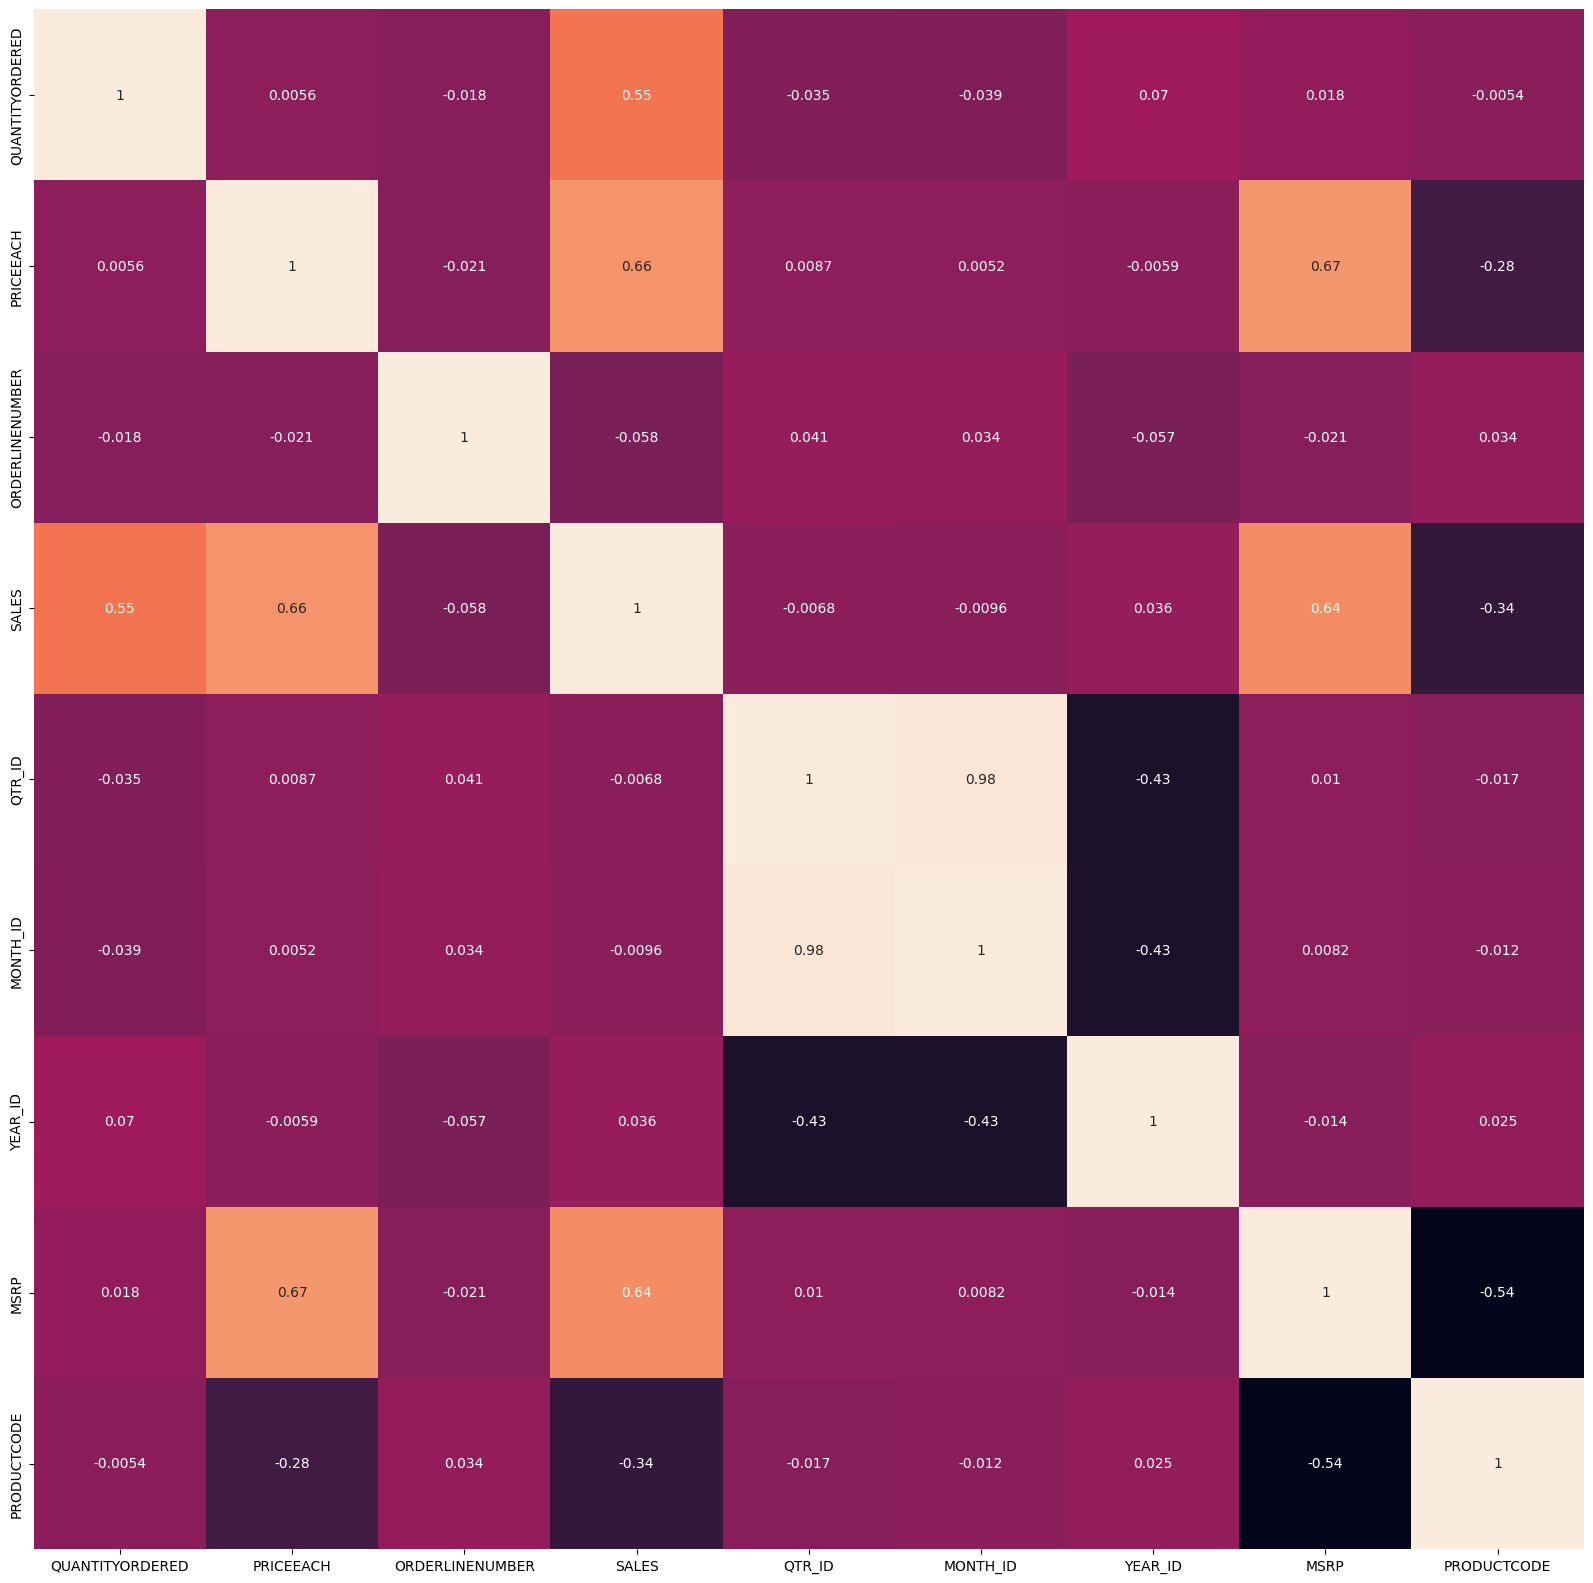

In [30]:
plt.figure(figsize=(20,20))
corr_matrix = sales_df.iloc[:,:9].corr()
sns.heatmap(corr_matrix, annot=True, cbar = False)

In [31]:
sales_df.drop("QTR_ID", axis=1, inplace = True)
sales_df.shape

(2823, 37)

In [32]:
# Vamos a representar distribuciones
# Distplot muestra el (1) histograma, (2) kde plot y (3) rug plot.
# (1) Histograma: es una visualización gráfica de datos que usa barras con varias alturas. Cada barra agrupa los números en rangos y las barras más altas muestran que hay más datos en ese rango.
# (2) Densidad: la estimación de la función de densidad se utiliza para visualizar la densidad de probabilidad de una variable continua.
# (3) Gráfico de alfombra: gráfico de datos para una única variable cuantitativa, que se muestra como marcas a lo largo de un eje (gráfico de dispersión unidimensional).

import plotly.figure_factory as ff

plt.figure(figsize = (10, 10))

for i in range(8):
  if sales_df.columns[i] != 'ORDERLINENUMBER':
    col_name = sales_df.columns[i]
    fig = ff.create_distplot([sales_df[col_name].apply(lambda x: float(x))], ['distplot'])
    fig.update_layout(title_text = col_name)
    fig.show()

<Figure size 1000x1000 with 0 Axes>

In [33]:
# Visualize the relationship between variables using pairplots
plt.figure(figsize = (20, 20))

fig = px.scatter_matrix(sales_df,
    dimensions = sales_df.columns[:8], color = 'MONTH_ID')

fig.update_layout(
    title = 'Sales Data',
    width = 1300,
    height = 1300,
)
fig.show()

# A trend exists between 'SALES' and 'QUANTITYORDERED'
# A trend exists between 'MSRP' and 'PRICEEACH'
# A trend exists between 'PRICEEACH' and 'SALES'
# It seems that sales growth exists as we move from 2013 to 2014 to 2015 ('SALES' vs. 'YEAR_ID')
# zoom in into 'SALES' and 'QUANTITYORDERED', you will be able to see the monthly information color coded on the graph

<Figure size 2000x2000 with 0 Axes>

In [34]:
# Visualizar la relacion entre las variables usando parcelas
plt.figure(figsize=(15,(15)))

fig = px.scatter_matrix(sales_df,dimensions=sales_df.columns[:8], color = 'MONTH_ID')

fig.update_layout(
    title = 'Sales Data',
    width = 1100,
    height = 1100,
)

<Figure size 1500x1500 with 0 Axes>

# Tarea 5
entender ela teoria y la intuicion detras del clustergin con KMEAN

Tarea 6
Encontrar el numeor optimo de clusters usando el mtodo de codo

In [35]:
# Escalar los datos
scaler = StandardScaler()
sales_df_scaled = scaler.fit_transform(sales_df)

In [36]:
sales_df_scaled.shape

(2823, 37)

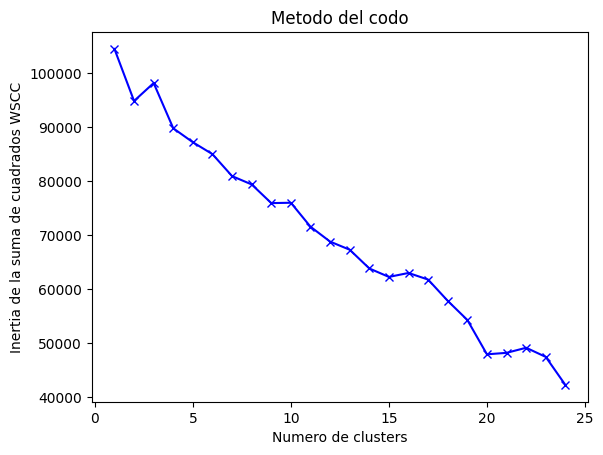

In [37]:
scores=[]

range_values = range(1,25)
for i in range_values:
  kmeans = KMeans(n_clusters = i)
  kmeans.fit(sales_df_scaled)
  scores.append(kmeans.inertia_)#la inercia es la suma de los cuadrados de las distancias de las observaciones al centro del cluster más cercano

plt.plot(range_values, scores, 'bx-')
plt.xlabel('Numero de clusters')
plt.ylabel('Inertia de la suma de cuadrados WSCC')
plt.title('Metodo del codo')
plt.show()

In [38]:
# Detalles de Kmeans en Sklearn: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
# A partir de esto podemos observar que, el 5º grupo parece estar formando el codo de la curva.
# Tengamos en cuenta que la curva cambiará cada vez que ejecutemos la celda


# Tarea 7 Aplicar metodo KMEANS

In [39]:
# Agrupar los clusters
kmeans = KMeans(5)
kmeans.fit(sales_df_scaled)
labels=kmeans.labels_

In [40]:
labels

array([2, 2, 4, ..., 4, 2, 4], dtype=int32)

In [41]:
kmeans.cluster_centers_.shape

(5, 37)

In [42]:
cluster_centers = pd.DataFrame(data = kmeans.cluster_centers_, columns = [sales_df.columns])
cluster_centers

,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,MONTH_ID,YEAR_ID,MSRP,PRODUCTCODE,Australia,Austria,...,Classic Cars,Motorcycles,Planes,Ships,Trains,Trucks and Buses,Vintage Cars,Large,Medium,Small
0,1.232059,0.799826,-0.252970,2.573414,-0.061517,0.122325,1.426162,-0.860383,-0.077488,0.050698,...,0.548098,0.026659,-0.156951,-0.300637,-0.126797,-0.195268,-0.136500,4.120788,-0.980703,-0.912100
1,-0.238120,-0.111504,0.374193,-0.305340,0.129536,-0.099789,-0.205639,0.209124,-0.264819,-0.140961,...,-0.304345,-0.305805,0.592055,-0.095340,0.006298,-0.284337,0.418106,-0.242672,-0.150357,0.262666
2,-0.463902,-0.735494,0.039723,-0.813600,-0.007420,0.006923,-0.581404,0.278806,0.046547,-0.007650,...,-0.165889,0.039055,0.060821,0.051727,0.058783,-0.025262,0.075971,-0.242672,-0.980703,1.096370
3,-0.022567,0.183672,-0.031440,0.187405,-0.012264,-0.280243,0.189983,-0.018958,-0.264819,-0.140961,...,0.415414,-0.364452,-0.246557,0.505344,0.222340,-0.242611,-0.252919,0.172896,0.003610,-0.083208
4,0.301390,0.578804,-0.035840,0.460972,0.003965,0.001143,0.373319,-0.171084,0.000670,0.019329,...,0.092741,0.003605,-0.073449,-0.029103,-0.050203,0.080269,-0.075236,-0.242672,1.019676,-0.912100


In [43]:
clusters_centers = pd.DataFrame(data = kmeans.cluster_centers_, columns = [sales_df.columns])
clusters_centers

,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,MONTH_ID,YEAR_ID,MSRP,PRODUCTCODE,Australia,Austria,...,Classic Cars,Motorcycles,Planes,Ships,Trains,Trucks and Buses,Vintage Cars,Large,Medium,Small
0,1.232059,0.799826,-0.252970,2.573414,-0.061517,0.122325,1.426162,-0.860383,-0.077488,0.050698,...,0.548098,0.026659,-0.156951,-0.300637,-0.126797,-0.195268,-0.136500,4.120788,-0.980703,-0.912100
1,-0.238120,-0.111504,0.374193,-0.305340,0.129536,-0.099789,-0.205639,0.209124,-0.264819,-0.140961,...,-0.304345,-0.305805,0.592055,-0.095340,0.006298,-0.284337,0.418106,-0.242672,-0.150357,0.262666
2,-0.463902,-0.735494,0.039723,-0.813600,-0.007420,0.006923,-0.581404,0.278806,0.046547,-0.007650,...,-0.165889,0.039055,0.060821,0.051727,0.058783,-0.025262,0.075971,-0.242672,-0.980703,1.096370
3,-0.022567,0.183672,-0.031440,0.187405,-0.012264,-0.280243,0.189983,-0.018958,-0.264819,-0.140961,...,0.415414,-0.364452,-0.246557,0.505344,0.222340,-0.242611,-0.252919,0.172896,0.003610,-0.083208
4,0.301390,0.578804,-0.035840,0.460972,0.003965,0.001143,0.373319,-0.171084,0.000670,0.019329,...,0.092741,0.003605,-0.073449,-0.029103,-0.050203,0.080269,-0.075236,-0.242672,1.019676,-0.912100


In [44]:
cluster_centers=scaler.inverse_transform(clusters_centers)
cluster_centers = pd.DataFrame(data = cluster_centers, columns = [sales_df.columns])
cluster_centers
# Clúster 0 (más alto): este grupo representa a los clientes que compran artículos en una gran cantidad centrada en ~ 47, compran artículos en todos los rangos de precios inclinándose hacia artículos de alto precio de ~ 99. También corresponden a las ventas totales más altas alrededor de ~ 8296 y están activas durante todo el año. Son los mayores compradores de productos con un MSRP alto ~ 158.
# Clúster 1: este grupo representa a los clientes que compran artículos en cantidades variables ~ 35, tienden a comprar artículos de alto precio ~ 96. Sus ventas son un poco mejores en promedio ~ 4435, compran productos con el segundo MSRP más alto de ~ 133.
# Clúster 2 (más bajo): este grupo representa a los clientes que compran artículos en cantidades bajas ~ 30. Suelen comprar artículos de bajo precio ~ 68. Sus ventas ~ 2044 son más bajas que las de otros grupos y son extremadamente activos durante la temporada navideña. Compran productos con un MSRP bajo ~ 75.
# Clúster 3: este grupo representa a los clientes que solo están activos durante las vacaciones. compran en menor cantidad ~ 35, pero tienden a comprar artículos de precio promedio alrededor de ~ 86. También corresponden a ventas totales más bajas alrededor de ~ 3673, tienden a comprar artículos con MSRP alrededor de 102
# Clúster 4: este grupo representa a los clientes que compran artículos en cantidad variable ~ 39,

,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,MONTH_ID,YEAR_ID,MSRP,PRODUCTCODE,Australia,Austria,...,Classic Cars,Motorcycles,Planes,Ships,Trains,Trucks and Buses,Vintage Cars,Large,Medium,Small
0,47.092715,99.791589,5.397351,8292.931060,6.867550,2003.900662,158.019868,26.602649,4.635762e-02,2.649007e-02,...,0.602649,1.258278e-01,0.059603,-9.714451e-17,0.006623,0.046358,0.158940,1.000000e+00,-7.771561e-16,1.221245e-15
1,32.773585,81.409434,8.047170,2991.593208,7.566038,2003.745283,92.452830,60.377358,2.775558e-17,-3.469447e-17,...,0.198113,1.886792e-02,0.292453,5.660377e-02,0.028302,0.018868,0.386792,-6.938894e-17,4.150943e-01,5.849057e-01
2,30.574539,68.823107,6.634003,2055.613543,7.065327,2003.819933,77.354271,62.577889,7.705193e-02,1.842546e-02,...,0.263819,1.298157e-01,0.127303,9.715243e-02,0.036851,0.098827,0.246231,2.220446e-16,-1.054712e-15,1.000000e+00
3,34.873016,87.363333,6.333333,3899.002381,7.047619,2003.619048,108.349206,53.174603,1.387779e-17,6.938894e-18,...,0.539683,8.326673e-17,0.031746,2.222222e-01,0.063492,0.031746,0.111111,9.523810e-02,4.920635e-01,4.126984e-01
4,38.028266,95.333430,6.314744,4402.786600,7.106952,2003.815890,115.715814,48.370512,6.569901e-02,2.215432e-02,...,0.386555,1.184110e-01,0.085561,7.486631e-02,0.019099,0.131398,0.184110,-2.567391e-16,1.000000e+00,-8.215650e-15


In [45]:
labels.shape #Etiquetas de cluster asociados


(2823,)

In [46]:
labels.max()

np.int32(4)

In [47]:
labels.min()

np.int32(0)

In [48]:
y_kmeans = kmeans.fit_predict(sales_df_scaled)
y_kmeans

array([4, 4, 2, ..., 3, 3, 3], dtype=int32)

In [49]:
# Agregar una etiqueta que identifique el cluster relacionado a cada punto de datos
sales_df_cluster = pd.concat([sales_df, pd.DataFrame({'cluster': labels})], axis = 1)
sales_df_cluster

,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,MONTH_ID,YEAR_ID,MSRP,PRODUCTCODE,Australia,Austria,...,Motorcycles,Planes,Ships,Trains,Trucks and Buses,Vintage Cars,Large,Medium,Small,cluster
0,30,95.70,2,2871.00,2,2003,95,0,False,False,...,True,False,False,False,False,False,False,False,True,2
1,34,81.35,5,2765.90,5,2003,95,0,False,False,...,True,False,False,False,False,False,False,False,True,2
2,41,94.74,2,3884.34,7,2003,95,0,False,False,...,True,False,False,False,False,False,False,True,False,4
3,45,83.26,6,3746.70,8,2003,95,0,False,False,...,True,False,False,False,False,False,False,True,False,4
4,49,100.00,14,5205.27,10,2003,95,0,False,False,...,True,False,False,False,False,False,False,True,False,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2818,20,100.00,15,2244.40,12,2004,54,108,False,False,...,False,False,True,False,False,False,False,False,True,2
2819,29,100.00,1,3978.51,1,2005,54,108,False,False,...,False,False,True,False,False,False,False,True,False,4
2820,43,100.00,4,5417.57,3,2005,54,108,False,False,...,False,False,True,False,False,False,False,True,False,4
2821,34,62.24,1,2116.16,3,2005,54,108,False,False,...,False,False,True,False,False,False,False,False,True,2


In [50]:
sales_df['ORDERLINENUMBER']= sales_df['ORDERLINENUMBER'].apply(lambda x: float(x))

# Tarea 8 Aplicar el analisis de componentes principales y visualizar los resultados

In [51]:
#Reducir los datos originales para usar el PCA a 3 dimensiones para dimensionar los clusters
pca = PCA(n_components=3)
principalComponents = pca.fit_transform(sales_df_scaled)
principalComponents

array([[-0.48631933,  1.19523199, -1.00267727],
       [-0.78465471,  1.03283188, -1.4162651 ],
       [ 1.43146434, -0.12199648, -0.28129104],
       ...,
       [ 0.38985361, -4.12946409,  0.06056817],
       [-2.78886764, -2.38601395, -1.54986594],
       [-0.7054888 , -3.31242744,  0.51890644]])

In [52]:
pca_df = pd.DataFrame(data = principalComponents, columns = ['principal component 1', 'principal component 2', 'principal component 3'])
pca_df.head()

,principal component 1,principal component 2,principal component 3
0,-0.486319,1.195232,-1.002677
1,-0.784655,1.032832,-1.416265
2,1.431464,-0.121996,-0.281291
3,1.288425,0.218280,0.579360
4,1.976022,0.141698,1.061314


In [53]:
# Concatenar las etiquetas de los clusteres
pca_df = pd.concat([pca_df, pd.DataFrame({'cluster': labels})], axis = 1)
pca_df.head()

,principal component 1,principal component 2,principal component 3,cluster
0,-0.486319,1.195232,-1.002677,2
1,-0.784655,1.032832,-1.416265,2
2,1.431464,-0.121996,-0.281291,4
3,1.288425,0.218280,0.579360,4
4,1.976022,0.141698,1.061314,4


In [54]:
# Visualizar los clusters con 3D_scatterplot
fig = px.scatter_3d(pca_df, x='principal component 1', y='principal component 2', z='principal component 3', color = 'cluster', size_max = 18, opacity= 0.7)
fig.update_layout(margin = dict(l=0, r=0, b=0, t=0))


# Minireto 8
Cambia el numero de componotentes a 2, modifica el codigo y vuelve a ejecutar el modelo
Visualiza los clusters usando 2D

<Axes: xlabel='principal component 1', ylabel='principal component 2'>

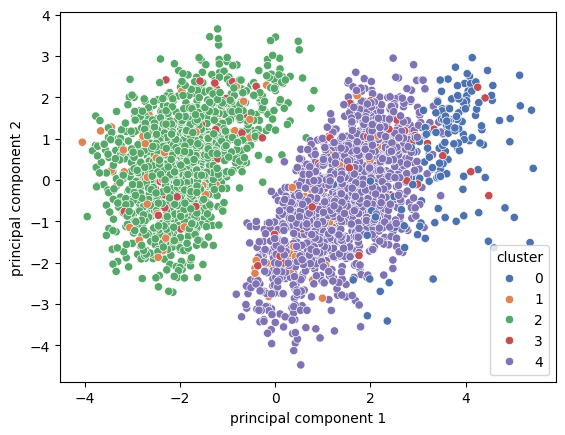

In [55]:
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(sales_df_scaled)

pca_df=pd.DataFrame(data = principalComponents, columns = ['principal component 1', 'principal component 2'])
pca_df = pd.concat([pca_df, pd.DataFrame({'cluster': labels})], axis = 1)

ax = sns.scatterplot(x = 'principal component 1', y = 'principal component 2', hue = 'cluster', data = pca_df, palette = 'deep')
ax

# Tarea9 Entender la teoria y la intuicion detras de autoencoders

In [56]:
#Tarea 10, Aplicar autoencoders(Realizar reduccion de dimensionalidad usando autoencoders)

In [57]:
sales_df.shape

(2823, 37)

In [58]:
input_df = Input(shape = (37,))
x = Dense(50, activation='relu')(input_df)
x = Dense(500, activation='relu', kernel_initializer= 'glorot_uniform')(x)
x = Dense(500, activation='relu', kernel_initializer= 'glorot_uniform')(x)
x = Dense(2000, activation='relu', kernel_initializer= 'glorot_uniform')(x)
encoded = Dense(8, activation='relu', kernel_initializer= 'glorot_uniform')(x)
x = Dense(2000, activation='relu', kernel_initializer= 'glorot_uniform')(encoded)
x = Dense(500, activation='relu', kernel_initializer= 'glorot_uniform')(x)
decoded = Dense(37, kernel_initializer= 'glorot_uniform')(x)

autoencoder = Model(input_df, decoded)

encoder = Model(input_df, encoded)

autoencoder.compile(optimizer='adam', loss='mean_squared_error')

In [ ]:
autoencoder.fit(sales_df_scaled, sales_df_scaled, batch_size= 120, epochs= 500, verbose=3)

Epoch 1/500
Epoch 2/500
Epoch 3/500
Epoch 4/500
Epoch 5/500
Epoch 6/500
Epoch 7/500
Epoch 8/500
Epoch 9/500
Epoch 10/500
Epoch 11/500
Epoch 12/500
Epoch 13/500
Epoch 14/500
Epoch 15/500
Epoch 16/500
Epoch 17/500
Epoch 18/500
Epoch 19/500
Epoch 20/500
Epoch 21/500
Epoch 22/500
Epoch 23/500
Epoch 24/500
Epoch 25/500
Epoch 26/500
Epoch 27/500
Epoch 28/500
Epoch 29/500
Epoch 30/500
Epoch 31/500
Epoch 32/500
Epoch 33/500
Epoch 34/500
Epoch 35/500
Epoch 36/500
Epoch 37/500
Epoch 38/500
Epoch 39/500
Epoch 40/500
Epoch 41/500
Epoch 42/500
Epoch 43/500
Epoch 44/500
Epoch 45/500
Epoch 46/500
Epoch 47/500
Epoch 48/500
Epoch 49/500
Epoch 50/500
Epoch 51/500
Epoch 52/500
Epoch 53/500
Epoch 54/500
Epoch 55/500
Epoch 56/500
Epoch 57/500
Epoch 58/500
Epoch 59/500
Epoch 60/500
Epoch 61/500
Epoch 62/500
Epoch 63/500
Epoch 64/500
Epoch 65/500
Epoch 66/500
Epoch 67/500
Epoch 68/500
Epoch 69/500
Epoch 70/500
Epoch 71/500
Epoch 72/500
Epoch 73/500
Epoch 74/500
Epoch 75/500
Epoch 76/500
Epoch 77/500
Epoch 78

In [ ]:
autoencoder.save_weights('autoencoder_1.weights.h5')

In [ ]:
pred = encoder.predict(sales_df_scaled)
pred.shape

89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


(2823, 8)

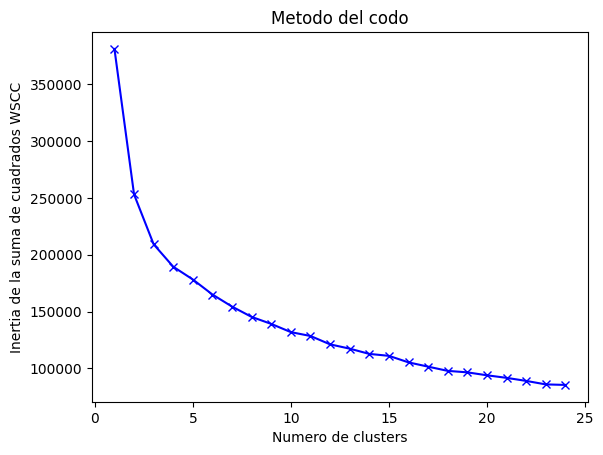

In [ ]:
scores = []

for i in range_values:
  kmeans = KMeans(n_clusters = i)
  kmeans.fit(pred)
  scores.append(kmeans.inertia_)

plt.plot(range_values, scores, 'bx-')
plt.xlabel('Numero de clusters')
plt.ylabel('Inertia de la suma de cuadrados WSCC')
plt.title('Metodo del codo')
plt.show()

In [ ]:
kmeans = KMeans(3)
kmeans.fit(pred)
labels=kmeans.labels_
y_kmeans = kmeans.fit_predict(sales_df_scaled)


In [ ]:
# ahora vamos a graficar los tres clusters
df_cluster_dr = pd.concat([pd.DataFrame(pred), pd.DataFrame({'cluster': labels})], axis = 1)
df_cluster_dr.head()

,0,1,2,3,4,5,6,7,cluster
0,0.311533,2.685679,0.0,1.467355,0.0,0.000000,2.861511,0.990459,1
1,0.055657,2.242183,0.0,3.882133,0.0,0.889770,1.895892,0.471295,1
2,8.498223,0.000000,0.0,6.396361,0.0,3.724705,4.977737,9.531332,2
3,0.933371,0.594094,0.0,1.975515,0.0,0.972440,5.423993,5.033771,1
4,0.835692,0.076259,0.0,2.454781,0.0,0.722067,5.481866,4.980830,1


In [ ]:
cluster_centers_autoencoder = scaler.inverse_transform(kmeans.cluster_centers_)
cluster_centers_autoencoder = pd.DataFrame(data = cluster_centers_autoencoder, columns = sales_df.columns)
display(cluster_centers_autoencoder)

,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,MONTH_ID,YEAR_ID,MSRP,PRODUCTCODE,Australia,Austria,...,Classic Cars,Motorcycles,Planes,Ships,Trains,Trucks and Buses,Vintage Cars,Large,Medium,Small
0,38.637773,96.282227,6.176180,4844.086596,7.075405,2003.809020,122.571529,43.125440,0.057787,0.022551,...,4.439746e-01,1.233263e-01,9.161381e-03,7.540521e-02,1.902748e-02,1.282593e-01,2.008457e-01,1.064130e-01,8.914729e-01,0.002114
1,34.774744,80.930785,7.375427,3030.607201,6.754266,2003.931741,85.740614,82.276451,0.085324,0.017065,...,-6.661338e-16,-8.187895e-16,1.000000e+00,4.163336e-16,-1.561251e-16,-2.914335e-16,-3.885781e-16,2.047782e-02,4.061433e-01,0.573379
2,30.648965,68.254608,6.596760,2044.016256,7.203420,2003.792079,76.749775,59.855986,0.070207,0.016202,...,3.033303e-01,1.404140e-01,-1.096345e-15,1.143114e-01,4.500450e-02,1.071107e-01,2.898290e-01,6.245005e-16,-1.054712e-15,1.000000


In [ ]:
clusters_centers = scaler.inverse_transform(kmeans.cluster_centers_)
clusters_centers = pd.DataFrame(data = clusters_centers, columns = sales_df.columns)
clusters_centers


,QUANTITYORDERED,PRICEEACH,ORDERLINENUMBER,SALES,MONTH_ID,YEAR_ID,MSRP,PRODUCTCODE,Australia,Austria,...,Classic Cars,Motorcycles,Planes,Ships,Trains,Trucks and Buses,Vintage Cars,Large,Medium,Small
0,38.637773,96.282227,6.176180,4844.086596,7.075405,2003.809020,122.571529,43.125440,0.057787,0.022551,...,4.439746e-01,1.233263e-01,9.161381e-03,7.540521e-02,1.902748e-02,1.282593e-01,2.008457e-01,1.064130e-01,8.914729e-01,0.002114
1,34.774744,80.930785,7.375427,3030.607201,6.754266,2003.931741,85.740614,82.276451,0.085324,0.017065,...,-6.661338e-16,-8.187895e-16,1.000000e+00,4.163336e-16,-1.561251e-16,-2.914335e-16,-3.885781e-16,2.047782e-02,4.061433e-01,0.573379
2,30.648965,68.254608,6.596760,2044.016256,7.203420,2003.792079,76.749775,59.855986,0.070207,0.016202,...,3.033303e-01,1.404140e-01,-1.096345e-15,1.143114e-01,4.500450e-02,1.071107e-01,2.898290e-01,6.245005e-16,-1.054712e-15,1.000000


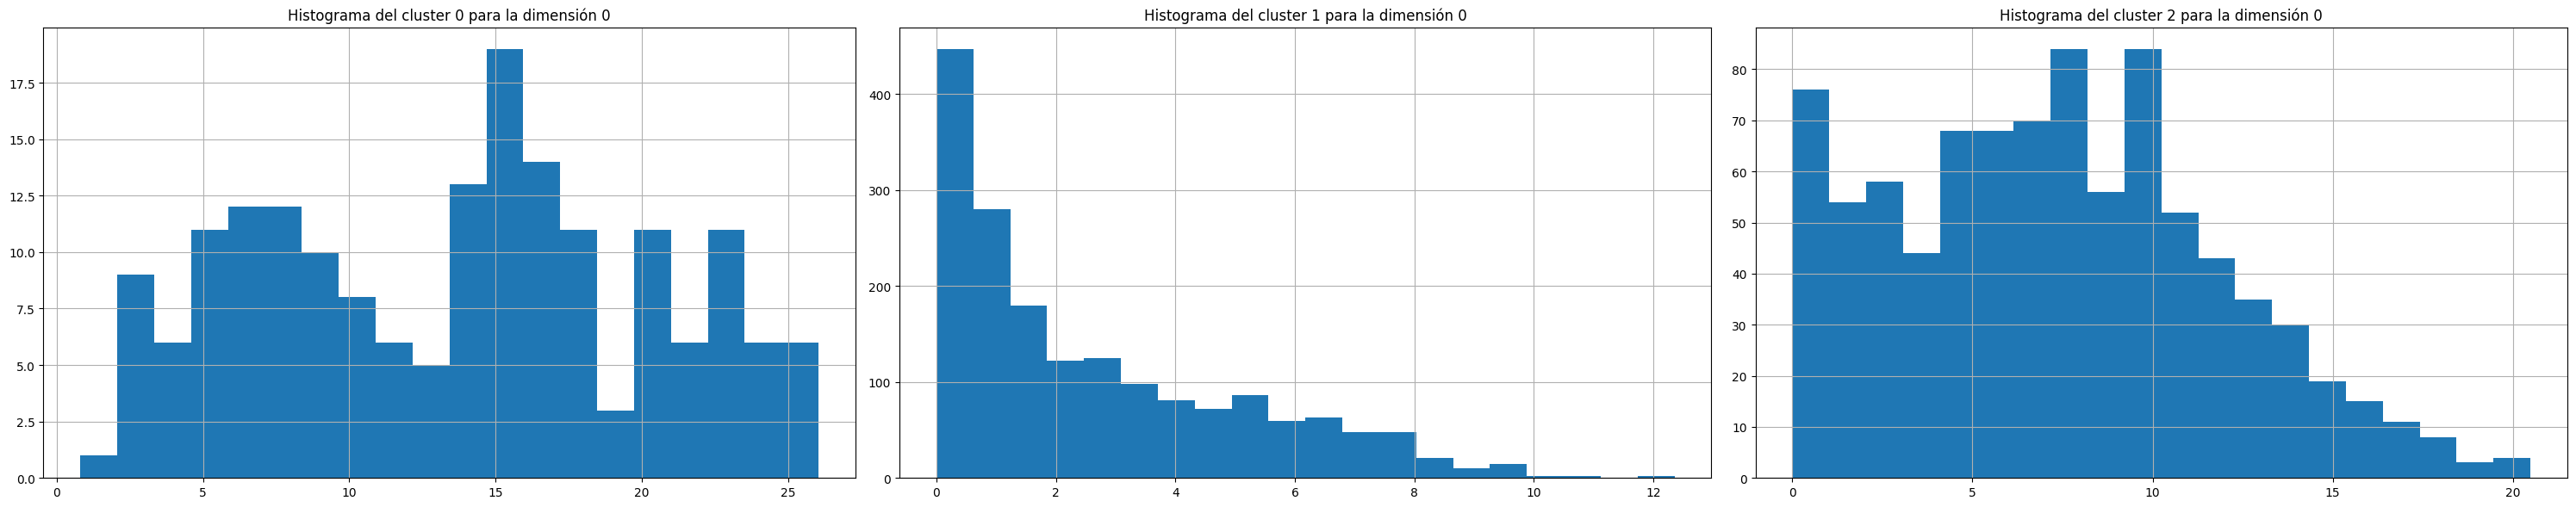

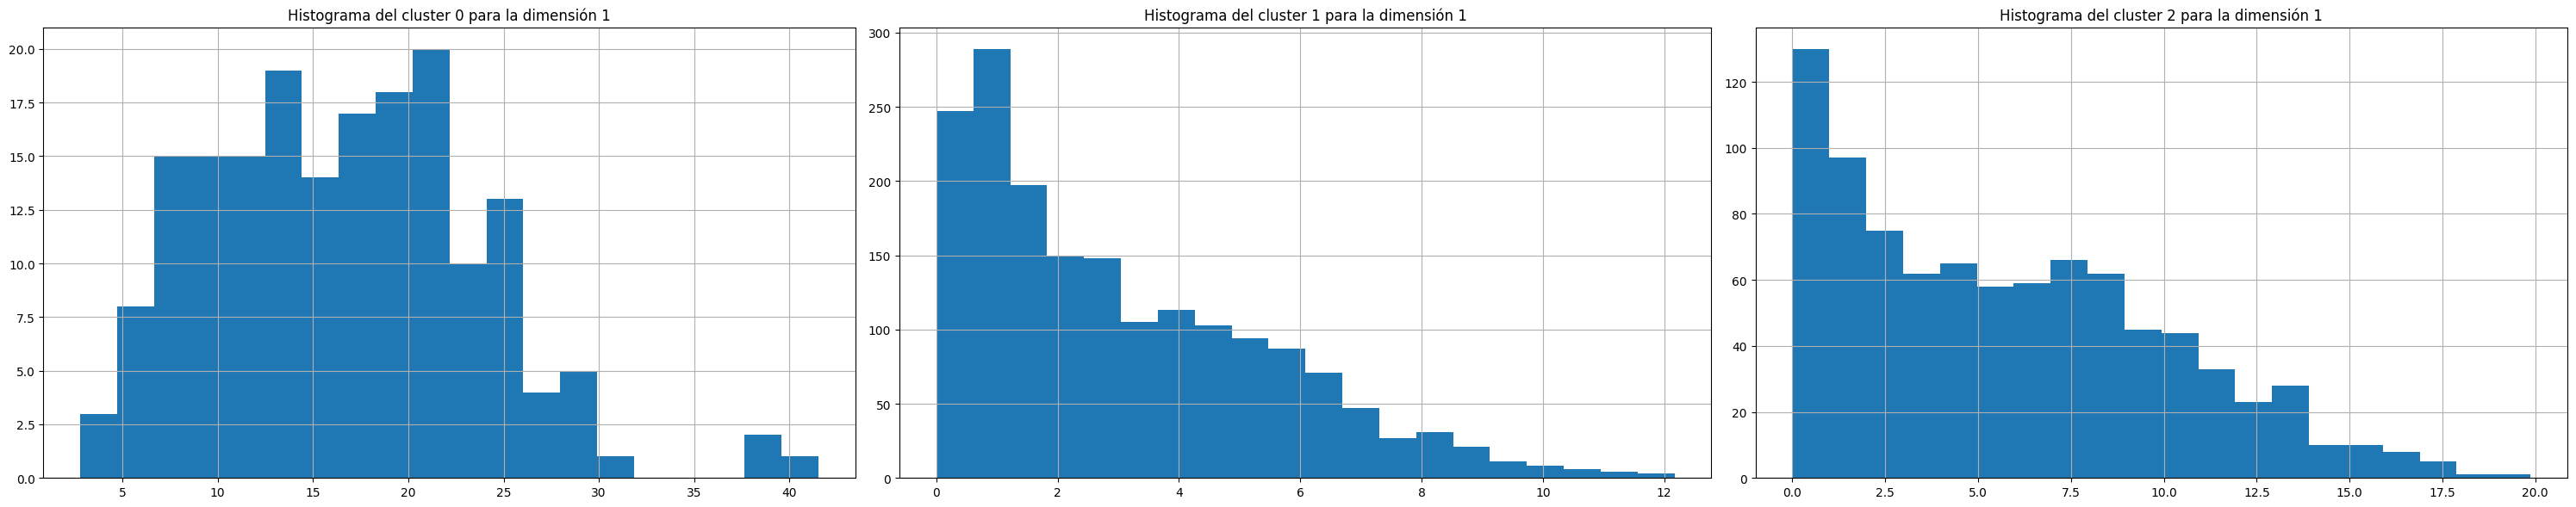

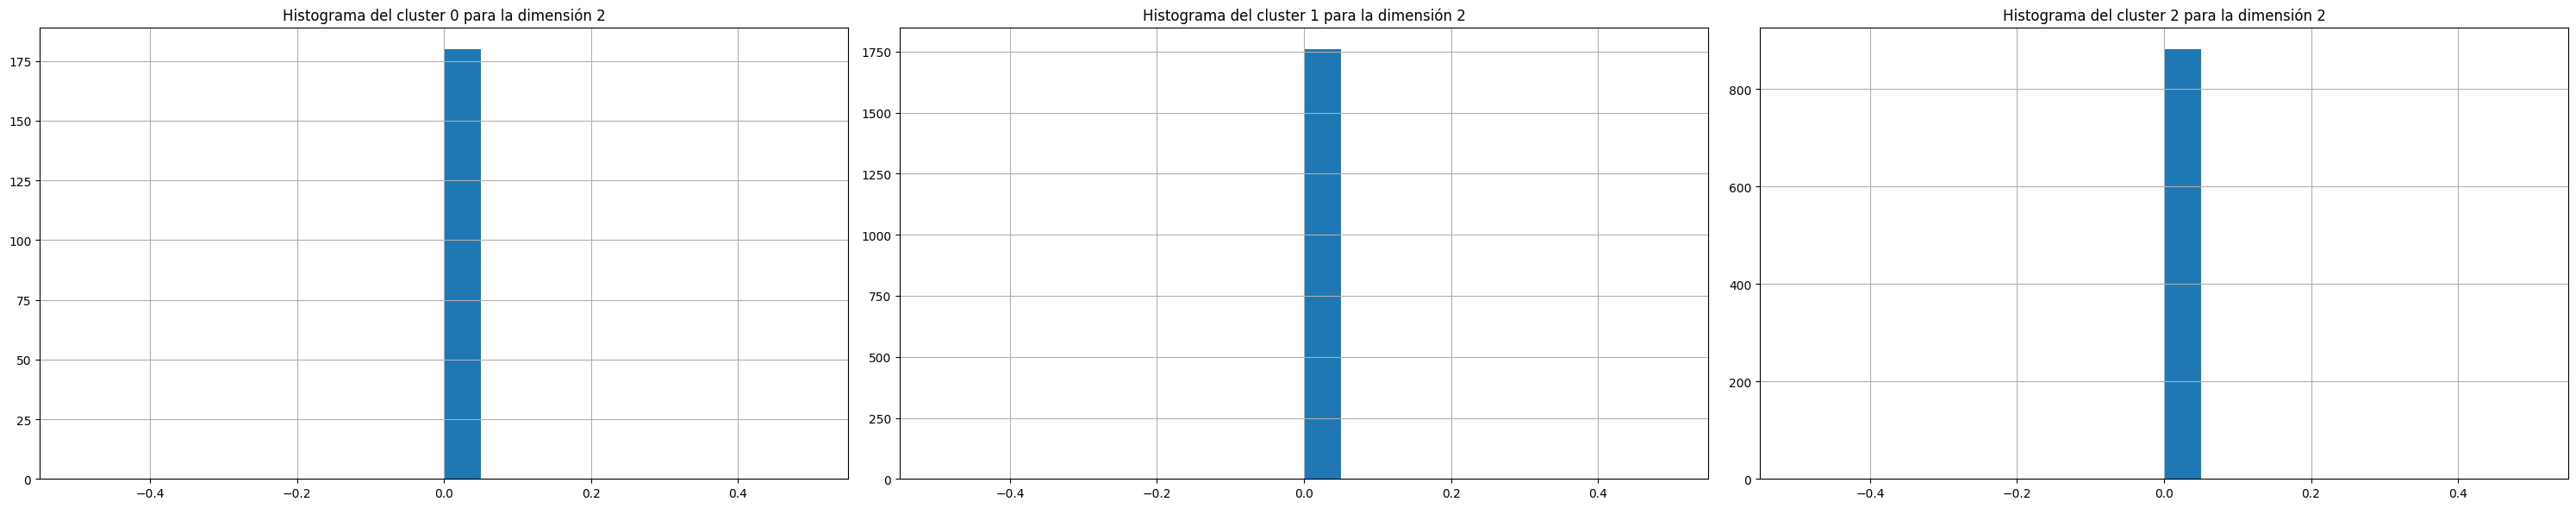

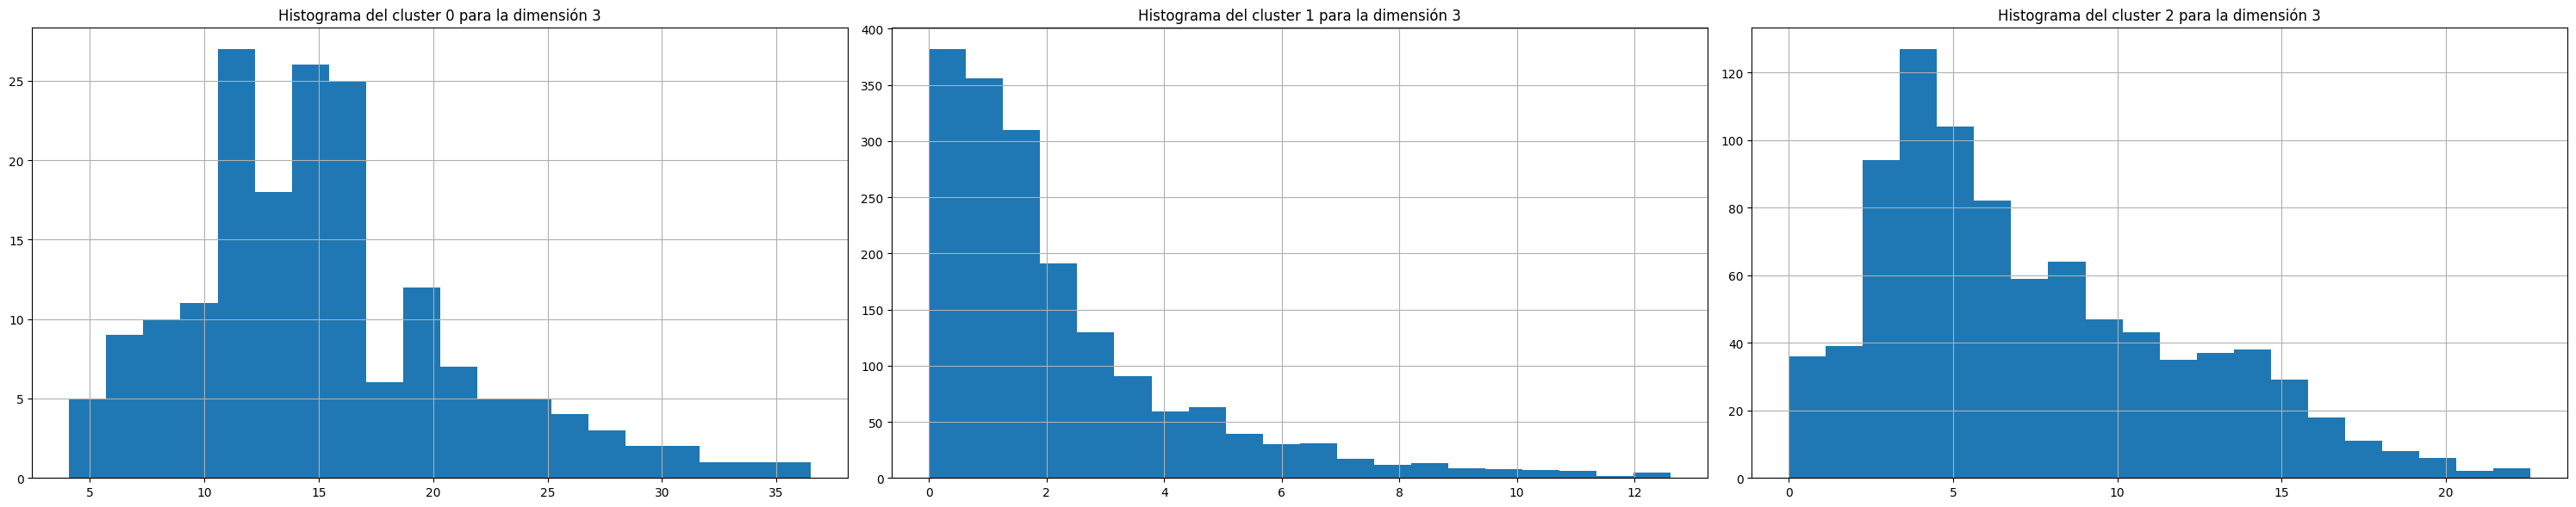

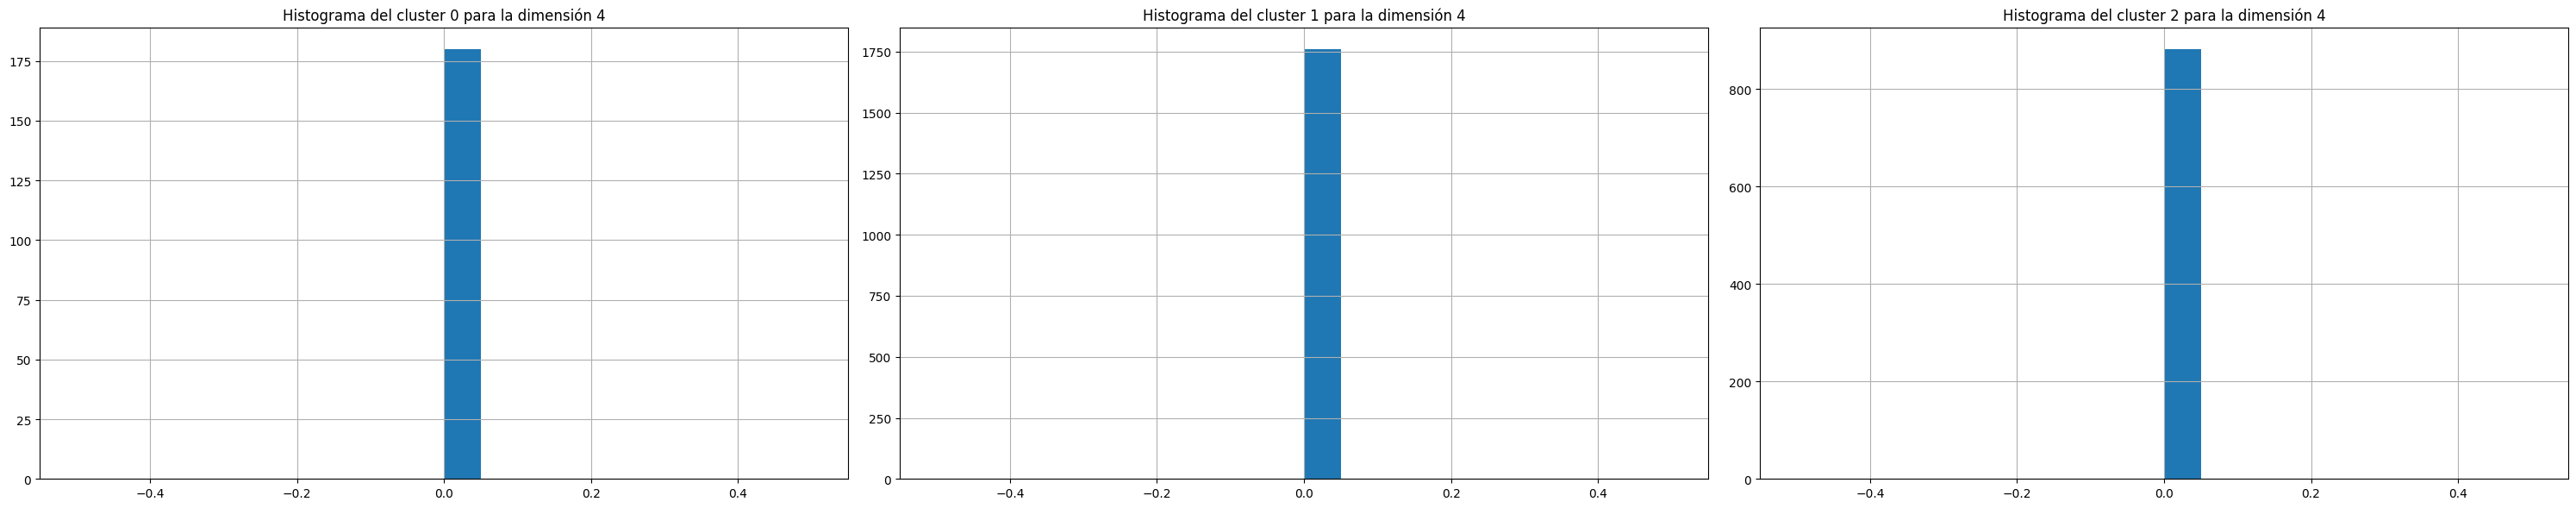

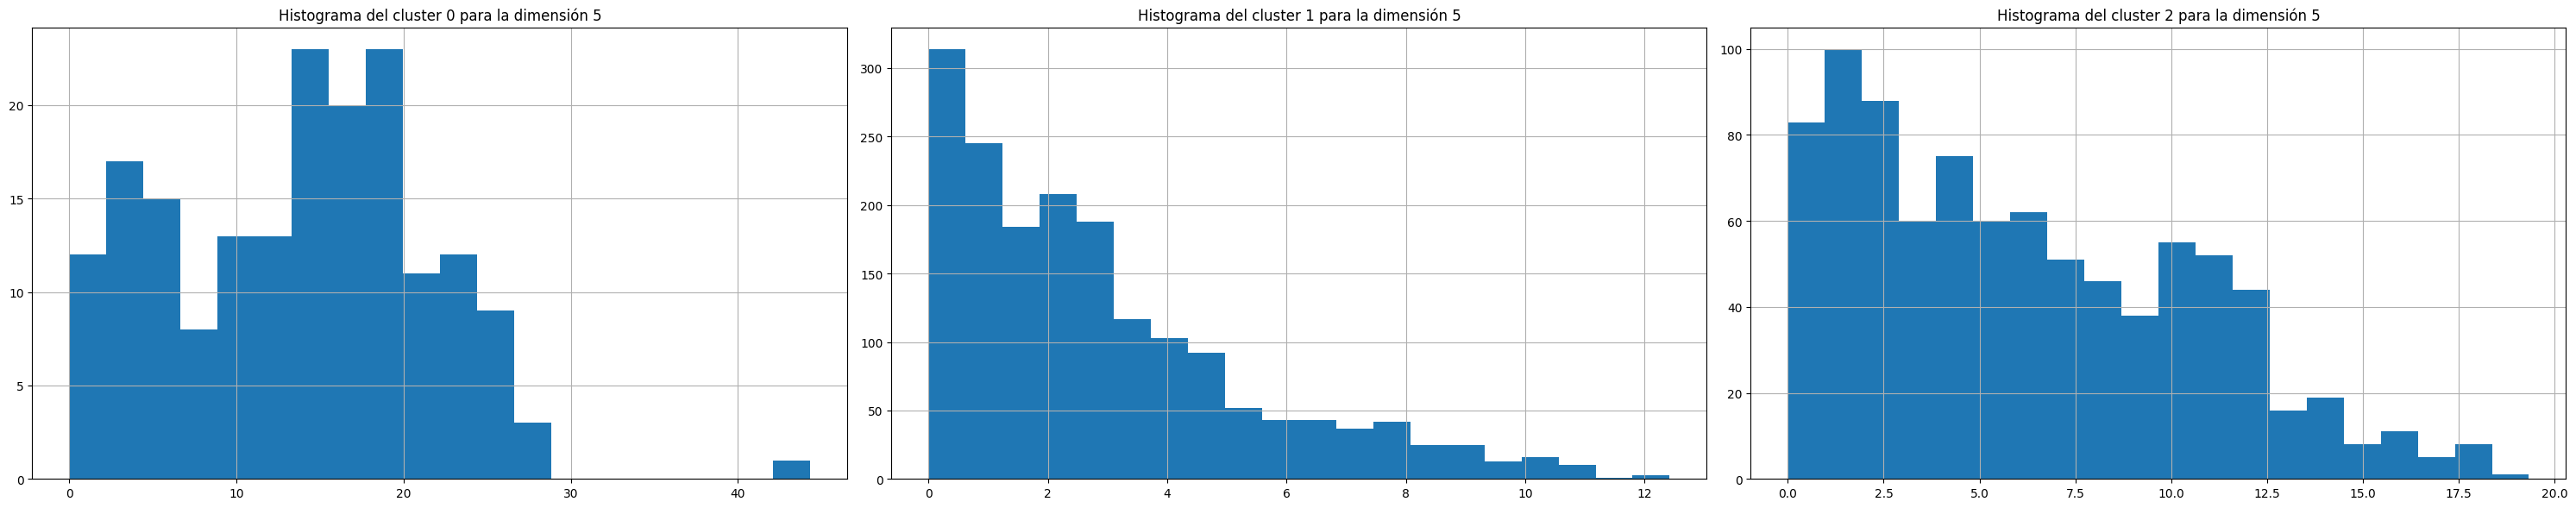

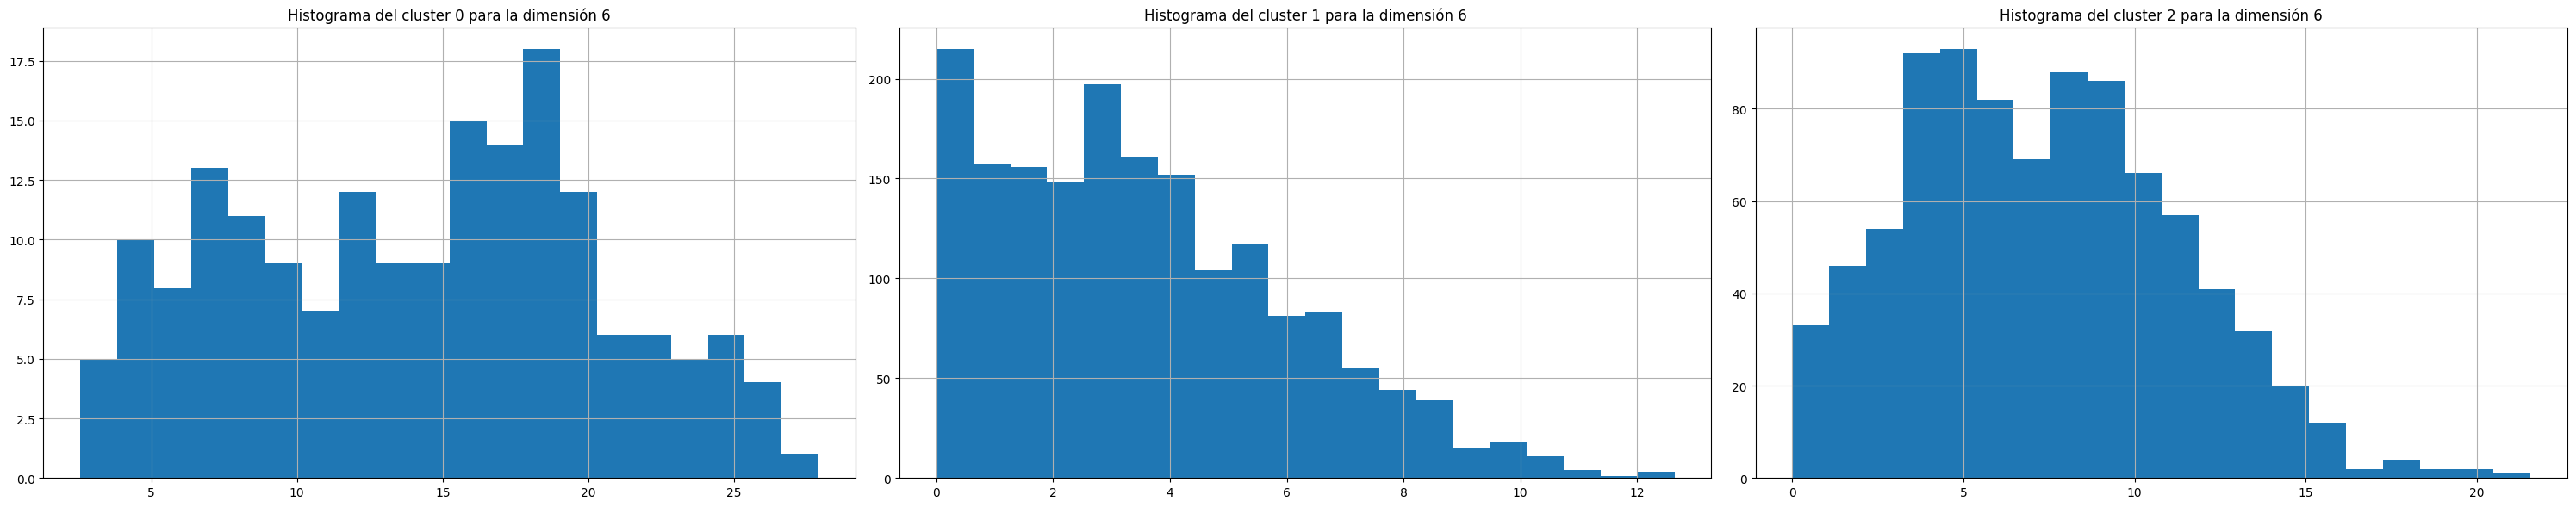

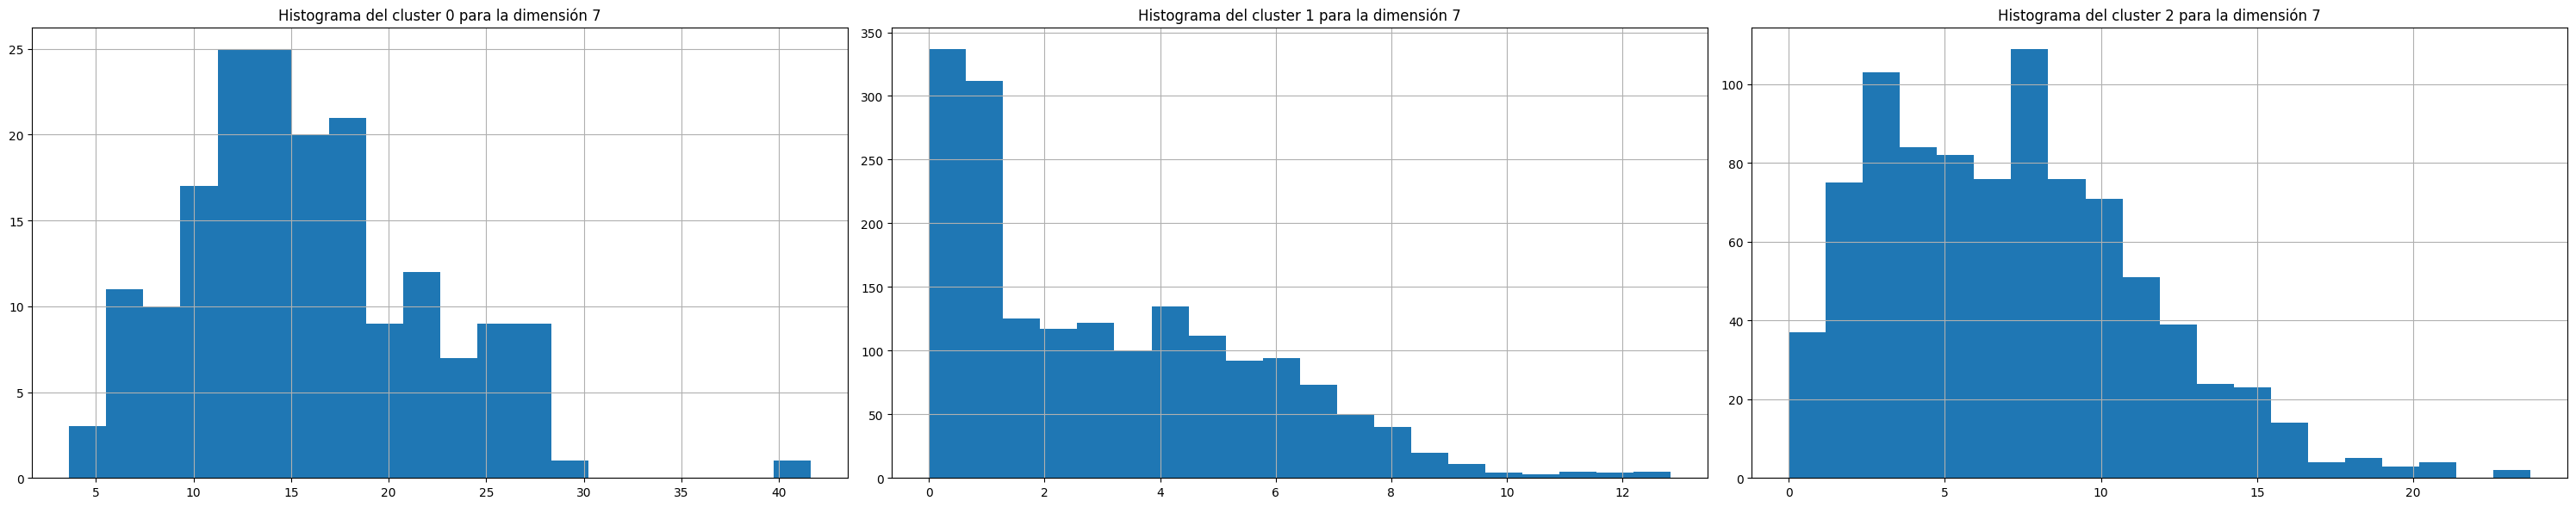

In [ ]:
# vamos a hacer un grafico de columnas con las caracteristicas del cluster
for col_idx in range(pred.shape[1]): # Iterar a través de las 8 dimensiones latentes
  plt.figure(figsize = (30, 6))
  for j in range(3): # Iterar a través de los 3 clusters
    plt.subplot(1, 3, j+1)
    cluster_data = df_cluster_dr[df_cluster_dr['cluster' ]== j]
    cluster_data[col_idx].hist(bins = 20)
    plt.title(f'Histograma del cluster {j} para la dimensión {col_idx}') # Título más descriptivo

  plt.tight_layout() # Ajustar el diseño para evitar superposiciones
  plt.show()

Clúster 0: este grupo representa a los clientes que compran artículos en gran cantidad (47), por lo general compran artículos con precios altos (99). Aportan más ventas que otros grupos. En su mayoría están activos durante todo el año. Suelen comprar productos correspondientes al código de producto 10-90. Compran productos con un alto mrsp (158).
# Clúster 1: este grupo representa a los clientes que compran artículos en cantidad promedio (37) y que compran tienden a comprar artículos de precio alto (95). Aportan un promedio de ventas (4398) y están activos todo el año, son los mayores compradores de los productos correspondientes a los códigos de producto 0-10 y 90-100, además prefieren comprar productos con un PVPR elevado (115).
# Clúster 2: este grupo representa a los clientes que compran artículos en pequeñas cantidades (30), tienden a comprar artículos de bajo precio (69). Corresponden a la venta total más baja (2061) y están activos durante todo el año. Son los mayores compradores de productos correspondientes a los códigos de producto 0-20 y 100-110 y luego compran productos con PVPR bajo (77).

In [ ]:
# Reducir los datos originales a 3 dimensiones usando ACP para visualizar los clusters
pca = PCA(n_components = 3)
comp = pca.fit_transform(sales_df_scaled)
print(comp)
pca_df = pd.DataFrame(data = comp)

[[-0.48631933  1.19523199 -1.00267727]
 [-0.78465471  1.03283188 -1.4162651 ]
 [ 1.43146434 -0.12199648 -0.28129104]
 ...
 [ 0.38985361 -4.12946409  0.06056817]
 [-2.78886764 -2.38601395 -1.54986594]
 [-0.7054888  -3.31242744  0.51890644]]


In [ ]:
pca_df = pd.DataFrame(data = comp, columns = ['principal component 1', 'principal component 2', 'principal component 3'])
pca_df = pd.concat([pca_df, pd.DataFrame({'cluster': labels})], axis = 1)

pca_df_cluster_0 = pca_df[pca_df['cluster'] == 0]

fig = px.scatter_3d(pca_df_cluster_0,
                    x='principal component 1',
                    y='principal component 2',
                    z='principal component 3',
                    color = 'cluster',
                    title='Cluster 0 en 3D (PCA)',
                    size_max = 18, opacity= 0.7)
fig.update_layout(margin = dict(l=0, r=0, b=0, t=0))
fig.show()

In [ ]:
# visualizando los clusters utilizando D.Scatterplot
fig = px.scatter_3d(pca_df, x='principal component 1', y='principal component 2', z='principal component 3',
                     color = 'cluster', symbol='cluster', size_max = 10, opacity=0.7)
fig.update_layout(margin = dict(l=0, r=0, b=0, t=0))
fig.show()

# Mini reto
convertir la fecha del pedido en formato de fecha y hora usando pandas.
verificar que la conversion sea exitosa imprimiendo el tipo de dato

In [ ]:
# Recargar el DataFrame original para asegurarse de que 'ORDERDATE' esté presente
sales_df = pd.read_csv('sales_data_sample.csv', encoding='latin1')

# Convertir la fecha del pedido en formato de fecha y hora
sales_df['ORDERDATE'] = pd.to_datetime(sales_df['ORDERDATE'])

# Verificar que la conversión es correcta imprimiendo el tipo de datos
sales_df.dtypes

,0
ORDERNUMBER,int64
QUANTITYORDERED,int64
PRICEEACH,float64
ORDERLINENUMBER,int64
SALES,float64
ORDERDATE,datetime64[ns]
STATUS,object
QTR_ID,int64
MONTH_ID,int64
YEAR_ID,int64


In [ ]:
# cuantos elementos nulois existen en ADDRESSLINE2?

sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823 entries, 0 to 2822
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ORDERNUMBER       2823 non-null   int64         
 1   QUANTITYORDERED   2823 non-null   int64         
 2   PRICEEACH         2823 non-null   float64       
 3   ORDERLINENUMBER   2823 non-null   int64         
 4   SALES             2823 non-null   float64       
 5   ORDERDATE         2823 non-null   datetime64[ns]
 6   STATUS            2823 non-null   object        
 7   QTR_ID            2823 non-null   int64         
 8   MONTH_ID          2823 non-null   int64         
 9   YEAR_ID           2823 non-null   int64         
 10  PRODUCTLINE       2823 non-null   object        
 11  MSRP              2823 non-null   int64         
 12  PRODUCTCODE       2823 non-null   object        
 13  CUSTOMERNAME      2823 non-null   object        
 14  PHONE             2823 n

In [ ]:
sales_df.nunique()

,0
ORDERNUMBER,307
QUANTITYORDERED,58
PRICEEACH,1016
ORDERLINENUMBER,18
SALES,2763
ORDERDATE,252
STATUS,6
QTR_ID,4
MONTH_ID,12
YEAR_ID,3


Cuantos valores de estado de pedido unicos tenemos?
tenemos conjuntos  de datos Balanceados? Comentar el resultado y proponer soluciones


In [ ]:
barplot_visualization('STATUS')

# los datos estan desbalanceados y en su mayoria contienen el estatus
sales_df.drop(columns= ['STATUS'], inplace = True)
sales_df.shape

(2823, 24)

Obtener dummies para la linea de productos y columnas de tamaño

In [ ]:
fig = px.line(x = sales_df_group.index, y = sales_df_group.SALES, title= 'Sales')
fig.show()

Mini reto 7 Representar la matriz de correlacion de resultado

/tmp/ipykernel_578/1828990503.py:7: UserWarning:

The palette list has more values (5) than needed (3), which may not be intended.



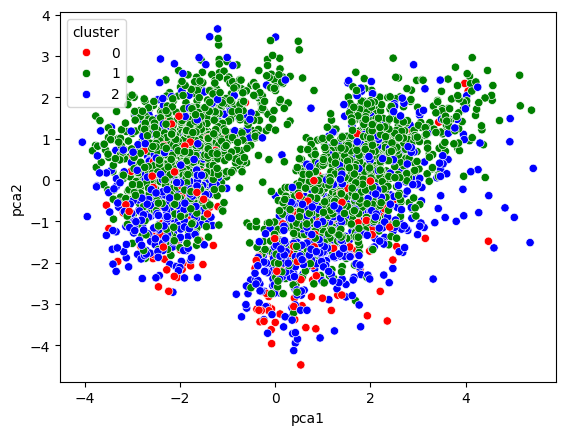

In [ ]:
pca = PCA(n_components = 2)
principal_comp = pca.fit_transform(sales_df_scaled)

pca_df = pd.DataFrame(data = principal_comp, columns = ['pca1', 'pca2'])
pca_df = pd.concat([pca_df, pd.DataFrame({'cluster':labels})], axis = 1)

ax = sns.scatterplot(x = "pca1", y = "pca2", hue = "cluster", data = pca_df, palette = ["red", "green", "blue", "pink", "yellow"])
plt.show()